In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.PointSourceResponse import PointSourceResponse

from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize, fsolve
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

15:13:00 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=864339;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=851378;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=566764;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=758400;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=779867;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=273143;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=57217;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=669727;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=25157;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=3647;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=811353;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=383208;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=275728;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=277295;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=320765;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=223213;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')

### Load Data

In [3]:
name = 'CasAsymmetric'
source = UnBinnedData("inputs.yaml")
source.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')

this_dict = source.get_dict_from_fits(source.data_file)

In [4]:
source_511 = UnBinnedData("inputs.yaml")
source_511.data_file = str(DATA_DIR / f'511/sources/511_testing_point_source_3months_unbinned_data_filtered_with_SAAcut.fits')

this_dict_511 = source_511.get_dict_from_fits(source_511.data_file)

In [5]:
source_crab = UnBinnedData("inputs.yaml")
source_crab.data_file = str(DATA_DIR / f'Crab/sources/crab_standard_3months_unbinned_data_filtered_with_SAAcut.fits')

this_dict_crab = source_crab.get_dict_from_fits(source_crab.data_file)

### Klein-Nishina Formula

In [6]:
import astropy.units as u
import astropy.constants as const

m_e = const.m_e
c = const.c
e = const.e.si
eps0 = const.eps0
PI = np.pi
r_e = 1 / (4 * PI * eps0) * (e**2 / (m_e * c**2))
r_e = r_e.to(u.fm)

def Compton_scattering_energy(phi, Ein):
    a = Ein / (m_e * c**2) * (1 - np.cos(phi))
    b = 1 + a   # denominator
    Eout = Ein / b
    return Eout

def Compton_scattering_energy_deposition(phi, Ein):
    return Ein - Compton_scattering_energy(phi, Ein)

def Compton_scattering_cross_section(Ein, phi, Eout):
    a = 1/2 * r_e**2 * (Eout/Ein)**2
    b = Ein/Eout + Eout/Ein - np.sin(phi)**2
    return a*b

def Compton_PDF(Ein, phi):
    Eout = Compton_scattering_energy(phi, Ein)
    cross_section = Compton_scattering_cross_section(Ein, phi, Eout)
    pdf = (cross_section[:-1] + cross_section[1:]) / 2 / cross_section.sum() / np.diff(-phi)
    return pdf

cosphi = np.linspace(-1, 1, 1001)
phi = np.arccos(cosphi)

pdf = Compton_PDF(Ein = 1157 * u.keV, phi = phi)

In [7]:
def threshold_deposition(phi, Ein):      # Estimate the minimum phi angle where Edep = Eth
    Eth = 18 * u.keV
    p = Compton_scattering_energy_deposition(phi, Ein)
    return (Eth - p).value

def Compton_degenerate_phi(angles, Ein):     # Estimate the pair of complementary angles that can simultaneously solve the Compton scattering equation
    phi1, phi2 = angles
    p = Compton_scattering_energy(phi1, Ein)
    q = Compton_scattering_energy(phi2, Ein)
    return [(Ein - p - q).value, np.pi - phi1 - phi2]

def Compton_scattering_energy_diff(phi, Ein, Eexpected):        # Estimate the angle such that energy deposited in first interaction is as close to Eexpected as possible
    Edep = Compton_scattering_energy_deposition(phi, Ein)
    return Eexpected - Edep

In [8]:
Ein = 1157 * u.keV

print(np.rad2deg(fsolve(threshold_deposition, np.pi/6, args=(Ein,))))

print(np.rad2deg(fsolve(Compton_degenerate_phi, [np.pi/3, 2*np.pi/3], args=(Ein,))))

[6.77342415]
[ 26.20975154 153.79024846]


In [9]:
Ein = 511 * u.keV
Compton_edge_2nd_int = Compton_scattering_energy(np.pi, Ein)

np.rad2deg(fsolve(Compton_scattering_energy_diff, np.pi/3, args=(Ein, Compton_edge_2nd_int)))

array([59.99986406])

In [10]:
def plot_phi_PDF(unbinned_dict, central_energy, window_energy, nbins, 
                 comparison_energy=None, normalization=None, ax=None):

    energies = unbinned_dict['Energies']
    phis = unbinned_dict['Phi']
    pdf = Compton_PDF(central_energy*u.keV, phi)

    idx = np.where(((central_energy - window_energy) < energies) & (energies < (central_energy + window_energy)))[0]
    counts, bins = np.histogram(phis[idx], bins = np.deg2rad(np.linspace(0, 180, nbins)))

    # Least squares fit the tail of the distribution and scale down
    # idx = [np.argmin(np.abs((phi[:-1] + phi[1:])/2 - b)) for b in bins]
    # norm_idx = int(np.ceil(0.6 * nbins))
    # f = lambda a: np.mean((pdf[idx][norm_idx:-1] - (counts / np.diff(bins) / counts.sum())[norm_idx:] / a)**2)    
    # if normalization is None:
    #     normalization = np.round(minimize(f, 1).x[0], 2)
    #     print(normalization)

    # Alternatively (11.4.25), ensure that the first 2/3rds of the plot falls 
    # strictly below the pdf curve
    if normalization is None:
        ts = 0.01
        a = 1
        while True:
            idx = [np.argmin(np.abs((phi[:-1] + phi[1:])/2 - b)) for b in bins[:2*nbins//3]]
            if all(pdf[idx] > (counts / np.diff(bins) / counts.sum() / a)[:2*nbins//3]):
                break
            else:
                a += ts
        normalization = a
        print(normalization)

    print(f'{np.round(1-1/normalization, 3)*100}% probability of rejecting an event because of its scatter angle')


    if ax is None:
        fig = plt.figure()
        ax = plt.gca()

    ax.stairs(counts / np.diff(bins) / counts.sum() / normalization, bins, fill=True, alpha=0.5, 
            label=f'{central_energy - window_energy} $-$ {central_energy + window_energy} keV')

    if comparison_energy is not None:
        idx = np.where(energies < comparison_energy)[0]
        counts, bins = np.histogram(phis[idx], bins = np.deg2rad(np.linspace(0, 180, 121)))
        plt.stairs(counts / np.diff(bins) / counts.sum() / 1.8, bins, color='k', alpha=0.5, lw=0.5, label = f'< {comparison_energy} keV')

    ax.plot((phi[:-1] + phi[1:])/2, pdf, ls='--', lw=1, label='Klein-Nishina')

    Ein = central_energy * u.keV
    phi_th = fsolve(threshold_deposition, np.pi/6, args=(Ein,))
    ax.axvline(phi_th, c='k', ls='dotted', alpha=0.8)
    if (central_energy - window_energy) > 511 / 2:
        # phi_deg = fsolve(Compton_degenerate_phi, [np.pi/3, 2*np.pi/3], args=(Ein,))
        # ax.axvline(phi_deg[0], c='limegreen', alpha=0.5)
        # ax.axvline(phi_deg[1], c='limegreen', alpha=0.5)

        Compton_edge_2nd_site = Compton_scattering_energy(np.pi, Ein)
        phi_Eunc = fsolve(Compton_scattering_energy_diff, np.pi/3, args=(Ein, Compton_edge_2nd_site))
        ax.axvline(phi_Eunc, c='hotpink', alpha=0.5)
        # print(phi_Eunc)

        E1 = (central_energy - window_energy) * u.keV
        C1 = Compton_scattering_energy(np.pi, E1)
        p1 = fsolve(Compton_scattering_energy_diff, np.pi/3, args=(E1, C1))
        E2 = (central_energy + window_energy) * u.keV
        C2 = Compton_scattering_energy(np.pi, E2)
        p2 = fsolve(Compton_scattering_energy_diff, np.pi/3, args=(E2, C2))
        # print(p1, p2)
        ax.axvspan(p1[0], p2[0], alpha=0.3, facecolor='pink')

        hardcode = np.deg2rad(35) #np.pi/6     # What I think is a hardcoded value (np.pi6) for the width. Value from Zoglauer 2005 thesis.
        ax.axvline(phi_Eunc + hardcode, c='hotpink', alpha=0.5)
        ax.axvspan(p1[0] + hardcode, p2[0] + hardcode, alpha=0.3, facecolor='pink')

    ax.set_xlabel('Phi (rad)')
    ax.set_ylabel('Probability Density')
    # ax.set_title(f'Comparison of Phi Distributions ({central_energy} keV)')
    ax.set_xticks([0, PI/4, PI/2, 3*PI/4, PI])
    ax.set_xticklabels([f'0', f'$\\pi/4$', f'$\\pi/2$', f'$3\\pi/4$', f'$\\pi$'])
    ax.set_ylim([0, 1])
    ax.text(0, 0.9, f'{np.round(1-1/normalization, 3)*100}%', va='top', fontdict={'fontsize': 14})
    ax.legend(fontsize=14)

1.6600000000000006
39.800000000000004% probability of rejecting an event because of its scatter angle


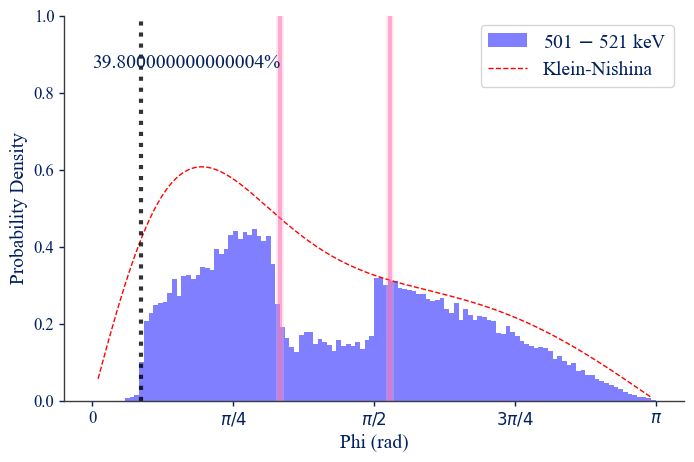

In [12]:
central_energy = 511
window_energy = 10
nbins = 121
fig, ax = plt.subplots(figsize=(8,5))
plot_phi_PDF(this_dict_crab, central_energy, window_energy, nbins, ax=ax)

1.6200000000000006
38.3% probability of rejecting an event because of its scatter angle
1.8000000000000007
44.4% probability of rejecting an event because of its scatter angle
1.6900000000000006
40.8% probability of rejecting an event because of its scatter angle
1.6200000000000006
38.3% probability of rejecting an event because of its scatter angle
1.7700000000000007
43.5% probability of rejecting an event because of its scatter angle
1.7700000000000007
43.5% probability of rejecting an event because of its scatter angle


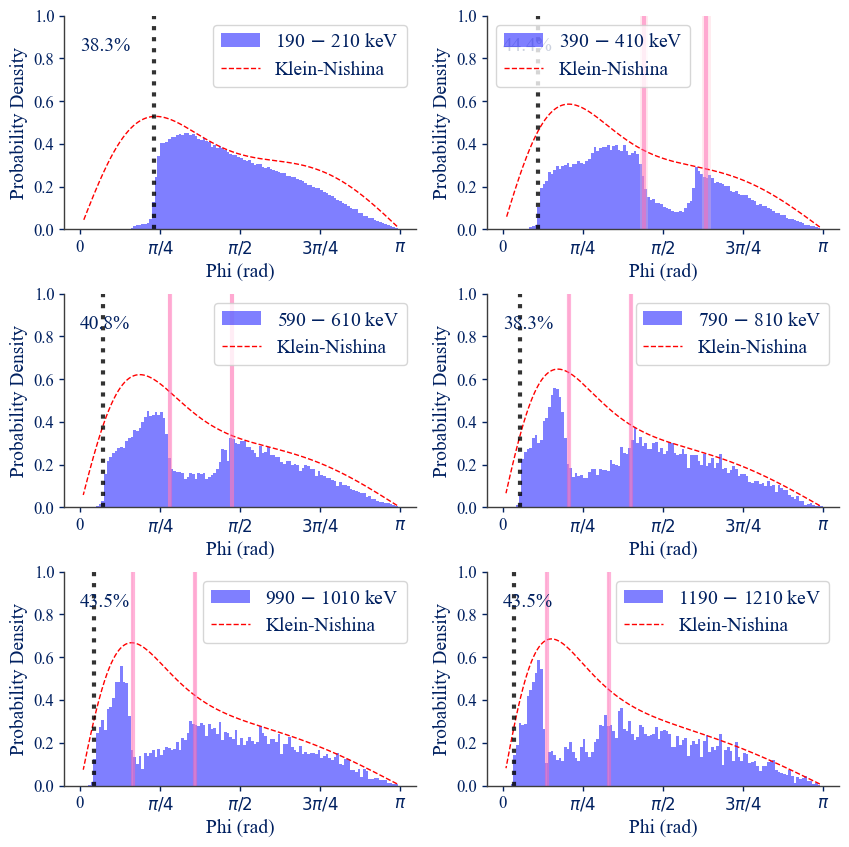

In [13]:
central_energies = [200, 400, 600, 800, 1000, 1200]
window_energy = 10
nbins = 121

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10,10))
plt.subplots_adjust(hspace=0.3)

for ax, central_energy in zip(axs.reshape(-1), central_energies):
    plot_phi_PDF(this_dict_crab, central_energy, window_energy, nbins, ax=ax)

Based on increasing values for the normalization constant: the photoelectric efficiency is decreasing with increasing energy (just as we expect).

However, at the same time, the normalization values are lower than what they should be (the histogram should be completely engulfed by the red dashed curve). So we are underestimating the normalization value at lower energies. TODO

In [ ]:
Compton_scattering_energy_deposition(np.deg2rad(41.7), 200*u.keV)

<Quantity 18.04342231 keV>

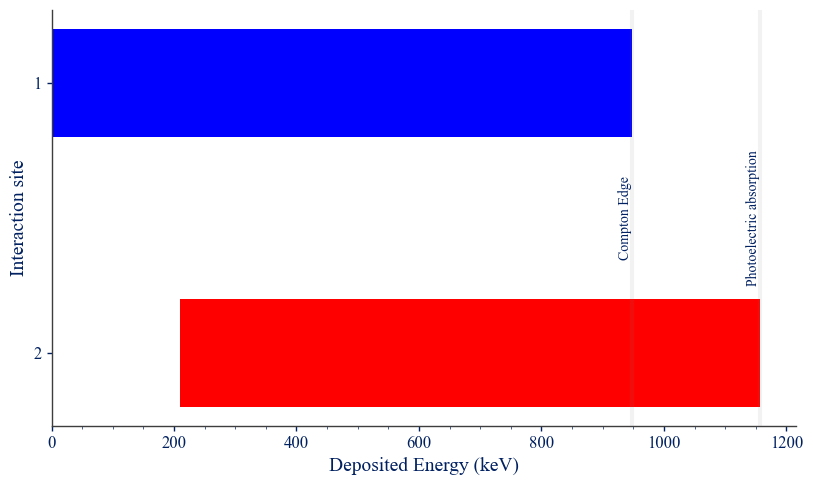

In [17]:
Ein = 1157 * u.keV
Compton_edge = Compton_scattering_energy_deposition(np.pi, Ein)

plt.barh(1, width = Compton_edge.value, left = 0)      # Interaction site 1
plt.barh(-1, width = Compton_edge.value, left = (Ein - Compton_edge).value)      # Interaction site 2

plt.axvline(Compton_edge.value, alpha=0.1, c='gray')
plt.text(Compton_edge.value, 0, 'Compton Edge', va='center', fontsize=10, ha='right', rotation=90)
plt.axvline(Ein.value, alpha=0.1, c='gray')
plt.text(Ein.value, 0, 'Photoelectric absorption', va='center', fontsize=10, ha='right', rotation=90)

plt.yticks([1, -1], labels=['1', '2'])
plt.ylabel('Interaction site')
plt.xlabel('Deposited Energy (keV)')
plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.show()

### Event Circle